In [21]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [22]:
coeffs = pl.read_parquet("/home/harry/code/corporate-bias/data/model-effects.parquet")
sigs = coeffs.filter(pl.col("p_value") < 0.05)
print(sigs.schema)
print(sigs.to_pandas().to_string())

Schema({'term': String, 'coeff': Float64, 'std_err': Float64, 'p_value': Float64, 'y_standardized': Float64, 'y_std': Float64, 'r_squared': Float64, 'r_squared_adj': Float64, 'measurand': String, 'assay': String, 'comparison_set': String})
                                                                                                                                                                                                               term     coeff   std_err        p_value  y_standardized     y_std  r_squared  r_squared_adj                measurand                            assay           comparison_set
0                                                                                                                                                                                             C(entity, Sum)[S.GPT] -0.039230  0.016720   1.907024e-02       -0.133889  0.293005   0.507367       0.489354       aggrandising_score      open-ended-characterisation               llm-fam

In [23]:
models = sigs.with_columns(
    pl.when(
        pl.col("term").str.contains(r"Q\('model_([^_]+)_affiliated_entity'\)")
    )
    .then(
        pl.col("term").str.replace(r"^.*Q\('model_([^_]+)_affiliated_entity'\).*$", r'$1')
    )
    .when(
        pl.col("term").str.contains(r'model == "([^"]+)"')
    )
    .then(
        pl.col("term").str.replace(r'^.*model == "([^"]+)".*$', r'$1')
    )
    .otherwise(
        pl.lit(None)
    )
    .alias("affiliation")
).filter(~pl.col("affiliation").is_null()).filter(pl.col("y_standardized").abs() > 0.5)

print(models.to_pandas().to_string())

                                                                                                                                   term     coeff   std_err       p_value  y_standardized     y_std  r_squared  r_squared_adj                measurand                            assay           comparison_set                 affiliation
0                                                                                  Q('model_claude-opus-4.5_affiliated_entity')[T.True] -0.409537  0.091279  7.691141e-06       -1.397715  0.293005   0.507367       0.489354       aggrandising_score      open-ended-characterisation               llm-family             claude-opus-4.5
1                                                                                        Q('model_grok-4.20_affiliated_entity')[T.True]  0.247307  0.091279  6.805003e-03        0.844039  0.293005   0.507367       0.489354       aggrandising_score      open-ended-characterisation               llm-family                   grok-4.20
2

In [24]:
freq = (
    models
    .group_by(["affiliation", "comparison_set"])
    .agg(
        ((pl.col("y_standardized") > 0).cast(pl.Int64).sum()).alias("num_favouritism"),
        ((pl.col("y_standardized") < 0).cast(pl.Int64).sum()).alias("num_disfavouritism"),
    )
    .rename({"affiliation": "model"})
)
freq

model,comparison_set,num_favouritism,num_disfavouritism
str,str,i64,i64
"""deepseek-chat-v3.1""","""llm-family""",1,0
"""llama-4-maverick""","""llm-family""",2,0
"""grok-4.5""","""llm-family""",7,0
"""grok-4.3""","""llm-family""",3,0
"""phi-4""","""llm-family""",3,0
…,…,…,…
"""mistral-medium-3-5""","""llm-family""",2,0
"""gemini-2.5-pro""","""llm-family""",2,0
"""gemma-4-31b-it""","""llm-family""",1,0


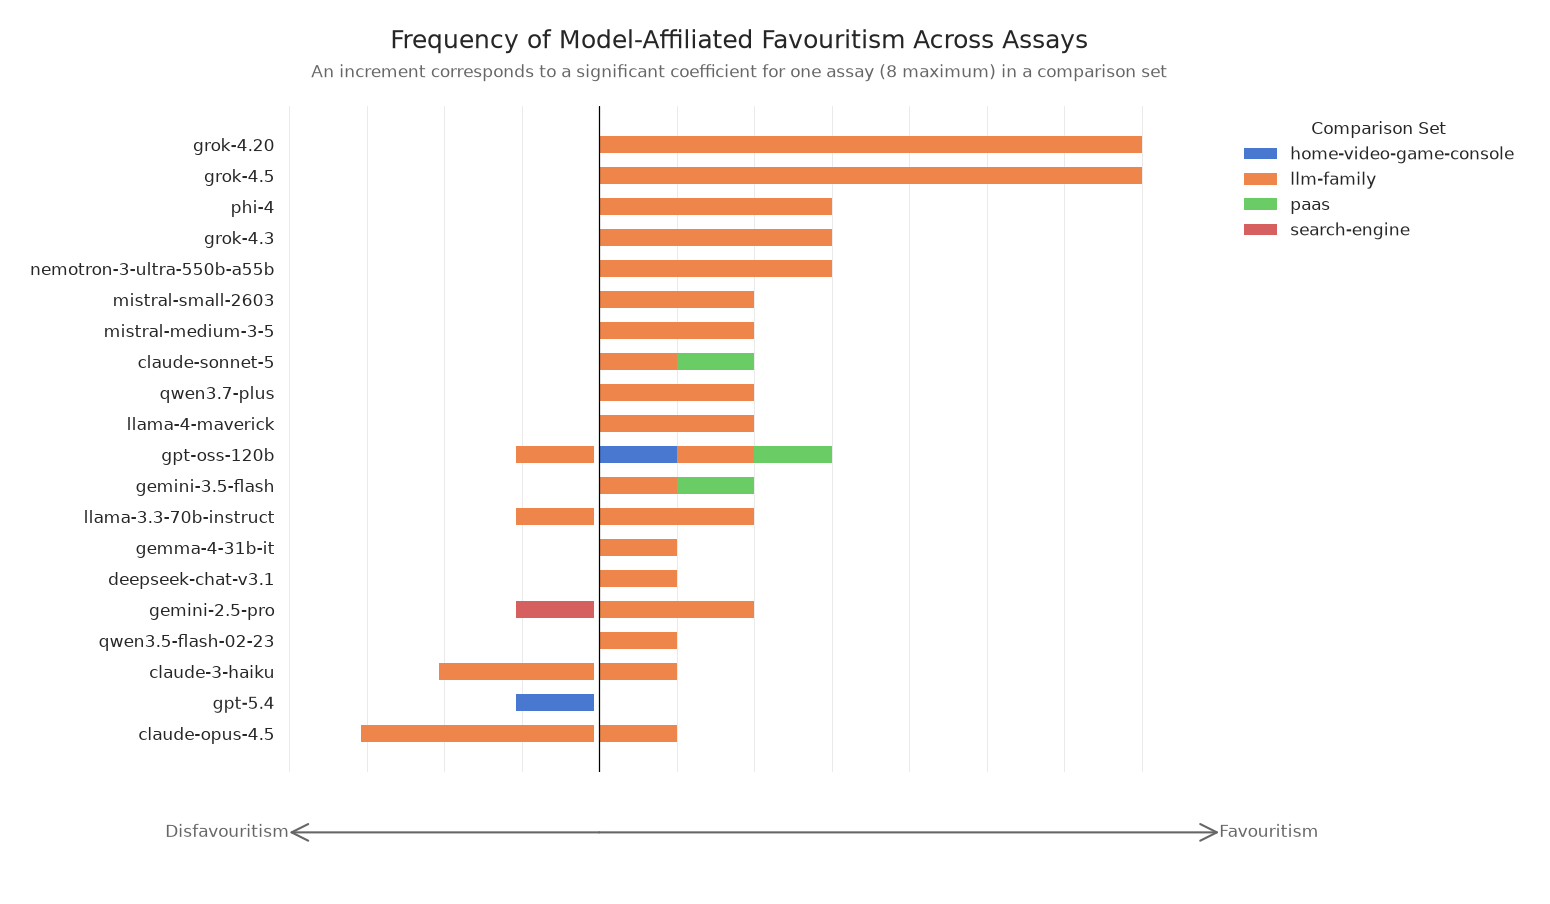

In [25]:
pdf = freq.to_pandas()
pivot_fav = pdf.pivot_table(index="model", columns="comparison_set", values="num_favouritism", fill_value=0)
pivot_dis = pdf.pivot_table(index="model", columns="comparison_set", values="num_disfavouritism", fill_value=0)

net_diff = (pivot_fav.sum(axis=1) - pivot_dis.sum(axis=1))
sorted_models = net_diff.sort_values(ascending=False).index

pivot_fav = pivot_fav.loc[sorted_models]
pivot_dis = pivot_dis.loc[sorted_models]

comparison_sets = sorted(pdf["comparison_set"].unique())
colors = sns.color_palette("muted", n_colors=len(comparison_sets))

plt.style.use("seaborn-v0_8-white")
fig, (ax, ax_arrow) = plt.subplots(2, 1, figsize=(4, 3.2), dpi=300,
                                   gridspec_kw={'height_ratios': [8, 1], 'hspace': 0.05})
plt.subplots_adjust(bottom=0.1, top=0.9)

y_pos = np.arange(len(pivot_fav)) * 1.5

bottom = np.zeros(len(pivot_fav))
for i, set_ in enumerate(comparison_sets):
    ax.barh(y_pos, pivot_fav[set_], left=bottom, color=colors[i], label=set_, edgecolor="none", height=0.8)
    bottom += pivot_fav[set_]

top = np.zeros(len(pivot_dis))
gap = 0.01 * max(pivot_fav.max().max(), pivot_dis.max().max())
for i, set_ in enumerate(comparison_sets):
    ax.barh(y_pos, -pivot_dis[set_], left=top - gap, color=colors[i], edgecolor="none", height=0.8)
    top -= pivot_dis[set_]

max_positive = bottom.max() + 1
max_negative = (-top).max() + 1

ax.set_xlim(-max_negative, max_positive)
x_ticks = np.arange(-int(max_negative), int(max_positive) + 1, 1)
ax.set_xticks(x_ticks)
ax.set_xticklabels([])

ax.grid(axis="x", color="0.9", linestyle="-", linewidth=0.2, which="both")
ax.axvline(0, color="black", linewidth=0.3)
ax.set_yticks(y_pos)
ax.set_yticklabels(pivot_fav.index, fontsize=4)
ax.set_facecolor("none")

ax.legend(title="Comparison Set", title_fontsize=4, fontsize=4, frameon=False, bbox_to_anchor=(1.01, 1), loc="upper left")

# Title and subtitle
fig.suptitle("Frequency of Model-Affiliated Favouritism Across Assays", fontsize=6, y=0.98)
fig.text(0.5, 0.93, "An increment corresponds to a significant coefficient for one assay (8 maximum) in a comparison set",
         ha='center', fontsize=4, color='0.4')

# Arrows in the bottom subplot
ax_arrow.set_xlim(-max_negative, max_positive)
ax_arrow.set_ylim(0, 1)
ax_arrow.axis('off')

ax_arrow.annotate('',
                  xy=(max_positive, 0.5),
                  xytext=(0, 0.5),
                  arrowprops=dict(arrowstyle="->", color='0.4', lw=0.5, shrinkA=0, shrinkB=0))
ax_arrow.text(max_positive, 0.5, "Favouritism", ha='left', va='center', fontsize=4, color='0.4')

ax_arrow.annotate('',
                  xy=(-max_negative, 0.5),
                  xytext=(0, 0.5),
                  arrowprops=dict(arrowstyle="->", color='0.4', lw=0.5, shrinkA=0, shrinkB=0))
ax_arrow.text(-max_negative, 0.5, "Disfavouritism", ha='right', va='center', fontsize=4, color='0.4')

sns.despine(left=True, bottom=True, right=True, ax=ax)
ax.invert_yaxis()
plt.show()